<a href="https://colab.research.google.com/github/vedant-sangrame/Machine-Learning/blob/main/Prac_10_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Vedant Sangrame (CS23163)**

**Aim: To Preform Heirarchical Clustering using agglomerative methods and interpret dendrograms for cluster formation.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/ML_dataset/Mall_Customers - Mall_Customers.csv"
df = pd.read_csv(path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

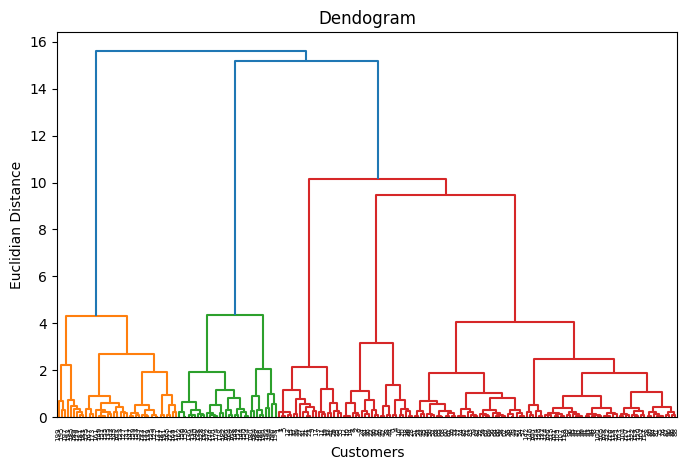

In [ ]:
plt.figure(figsize=(8, 5))

dendrogram(linkage(X_scaled, method='ward'))

plt.title("Dendogram")
plt.xlabel("Customers")
plt.ylabel("Euclidian Distance")
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
cluster = hc.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = cluster
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


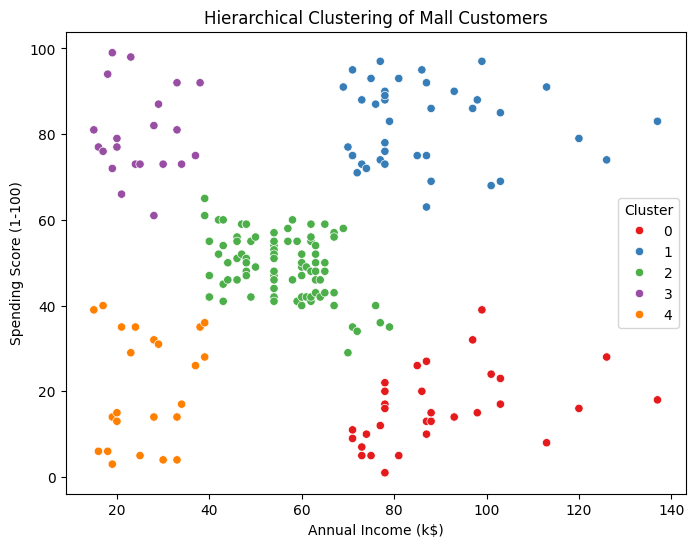

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                hue='Cluster',
                data=df,
                palette='Set1'
)

plt.title("Hierarchical Clustering of Mall Customers")
plt.show()